# Análisis de seguridad reproducible

Este notebook lee evidencia guardada; no descarga repositorios ni consulta un modelo de lenguaje.

In [1]:
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt
DATA_PATH = Path('../prepared/data.json')
data = json.loads(DATA_PATH.read_text(encoding='utf-8'))
data['summary']

{'repositories': 50,
 'expected_repositories': 50,
 'code_findings': 0,
 'dependency_findings': 582,
 'components': 5748,
 'coverage': {'codeql': {'failed': 48, 'unsupported': 2},
  'syft': {'success': 49, 'success_empty': 1},
  'grype': {'success': 21, 'success_empty': 29}}}

In [2]:
ESTADOS = {'success': 'completado', 'success_empty': 'sin resultados', 'partial': 'parcial', 'failed': 'fallido', 'skipped': 'omitido', 'unsupported': 'no compatible'}
SEVERIDADES = {'error': 'Error', 'warning': 'Advertencia', 'note': 'Nota', 'none': 'Ninguno', 'critical': 'Crítica', 'high': 'Alta', 'medium': 'Media', 'low': 'Baja', 'unknown': 'Desconocida'}

## Cobertura

El denominador incluye fallos, herramientas omitidas y lenguajes no compatibles.

In [3]:
summary = data['summary']
for tool, states in summary['coverage'].items():
    assert sum(states.values()) == summary['repositories']
    print(tool, {ESTADOS.get(estado, estado): cantidad for estado, cantidad in states.items()})
print('Muestra:', summary['repositories'], '/', summary['expected_repositories'])

codeql {'fallido': 48, 'no compatible': 2}
syft {'completado': 49, 'sin resultados': 1}
grype {'completado': 21, 'sin resultados': 29}
Muestra: 50 / 50


## Alertas de código y coincidencias de dependencias

Sus escalas de severidad se muestran por separado. Una coincidencia no demuestra que sea explotable.

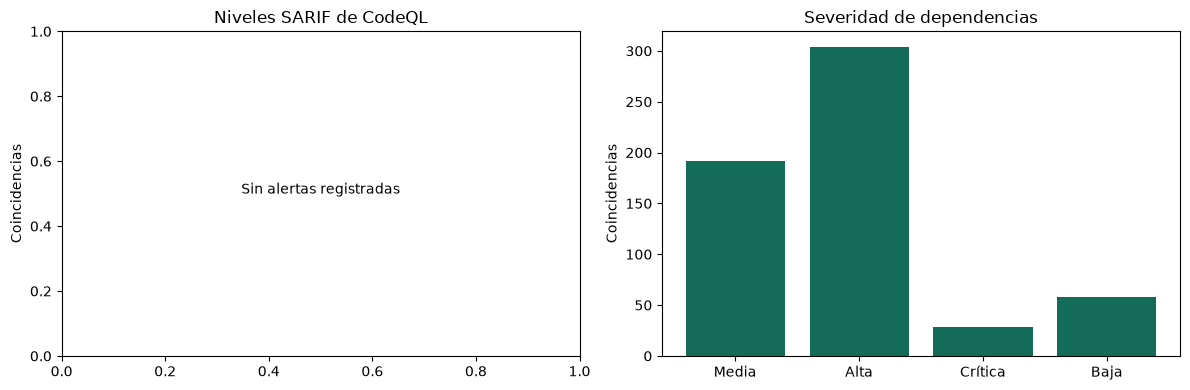

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, kind, title, total_key in zip(axes, ['code', 'dependency'], ['Niveles SARIF de CodeQL', 'Severidad de dependencias'], ['code_findings', 'dependency_findings']):
    items = [e for e in data['evidence'] if e['kind'] == kind]
    assert len(items) == summary[total_key]
    counts = Counter(e['detail']['severity'] for e in items)
    if counts:
        ax.bar([SEVERIDADES.get(str(nivel).lower(), nivel) for nivel in counts], counts.values(), color='#146b57')
    else:
        ax.text(.5, .5, 'Sin alertas registradas', ha='center', transform=ax.transAxes)
    ax.set_title(title)
    ax.set_ylabel('Coincidencias')
fig.tight_layout()
plt.show()

## Reglas, paquetes y distribución por repositorio

In [5]:
print('Reglas:', Counter(e['detail']['rule_id'] for e in data['evidence'] if e['kind']=='code').most_common(15))
print('Paquetes:', Counter(e['detail']['package_name'] for e in data['evidence'] if e['kind']=='dependency').most_common(15))
for repo in data['repositories']:
    print(repo['repository'], {t['tool']: (ESTADOS.get(t['status'], t['status']), t['count']) for t in repo['tools']})

Reglas: []
Paquetes: [('multer', 125), ('qs', 51), ('brace-expansion', 44), ('fast-uri', 43), ('react-router', 26), ('proxy-addr', 19), ('path-to-regexp', 17), ('undici', 16), ('body-parser', 15), ('minimatch', 12), ('@nestjs/core', 11), ('@nestjs/common', 11), ('protobufjs', 11), ('@nestjs/microservices', 11), ('ip-address', 10)]
nestjs/nest {'codeql': ('fallido', 0), 'syft': ('completado', 348), 'grype': ('completado', 5)}
nestjs/bull {'codeql': ('fallido', 0), 'syft': ('completado', 145), 'grype': ('completado', 4)}
nestjs/awesome-nestjs {'codeql': ('no compatible', 0), 'syft': ('completado', 15), 'grype': ('completado', 2)}
nestjs/observe {'codeql': ('fallido', 0), 'syft': ('completado', 8), 'grype': ('sin resultados', 0)}
nestjs/resilience {'codeql': ('fallido', 0), 'syft': ('completado', 5), 'grype': ('sin resultados', 0)}
nestjs/schematics {'codeql': ('fallido', 0), 'syft': ('completado', 38), 'grype': ('completado', 9)}
nestjs/workflows {'codeql': ('fallido', 0), 'syft': ('comp

## Comparación por categoría

Los conteos observados se leen junto con la cobertura de cada herramienta; no son tasas de vulnerabilidad.

In [6]:
from collections import defaultdict
by_category = defaultdict(lambda: {'repositorios': 0, 'codeql_completos': 0, 'grype_completos': 0, 'codigo': 0, 'dependencias': 0})
for repo in data['repositories']:
    group = by_category[repo.get('category') or 'Sin categoría']
    group['repositorios'] += 1
    for tool in repo['tools']:
        if tool['tool'] in ('codeql', 'grype') and tool['status'] in ('success', 'success_empty'):
            group[tool['tool'] + '_completos'] += 1
for item in data['evidence']:
    if item['kind'] in ('code', 'dependency'):
        by_category[item.get('category') or 'Sin categoría']['codigo' if item['kind'] == 'code' else 'dependencias'] += 1
for category, counts in sorted(by_category.items()):
    print(category, counts)

CSS {'repositorios': 1, 'codeql_completos': 0, 'grype_completos': 1, 'codigo': 0, 'dependencias': 12}
JavaScript {'repositorios': 1, 'codeql_completos': 0, 'grype_completos': 1, 'codigo': 0, 'dependencias': 8}
Sin lenguaje principal {'repositorios': 1, 'codeql_completos': 0, 'grype_completos': 1, 'codigo': 0, 'dependencias': 2}
TypeScript {'repositorios': 47, 'codeql_completos': 0, 'grype_completos': 47, 'codigo': 0, 'dependencias': 560}


## Patrones observados y cobertura

Estas comparaciones describen hallazgos observados. La cobertura desigual impide interpretarlos como tasas de vulnerabilidad de toda la organización.

In [7]:
from collections import defaultdict
for kind, tool_name, label in [('code', 'codeql', 'alertas de código'),
                               ('dependency', 'grype', 'coincidencias de dependencias')]:
    items = [e for e in data['evidence'] if e['kind'] == kind]
    covered = [r['repository'] for r in data['repositories']
               if any(t['tool'] == tool_name and t['status'] in ('success', 'success_empty')
                      for t in r['tools'])]
    by_repository = Counter(e['repository'] for e in items)
    print(f'{label}: cobertura completa en {len(covered)}/{len(data["repositories"])} repositorios')
    if items:
        name, count = by_repository.most_common(1)[0]
        print(f'  Mayor concentración observada: {name}, {count}/{len(items)} ({count / len(items):.1%}).')
        print('  Repositorios con hallazgos observados:', len(by_repository),
              '(puede incluir resultados parciales).')
    else:
        print('  No hay hallazgos registrados; revisa la cobertura antes de interpretar este resultado.')
rules_to_repositories = defaultdict(set)
for finding in data['evidence']:
    if finding['kind'] == 'code':
        rules_to_repositories[finding['detail']['rule_id']].add(finding['repository'])
repeated = sorted(((rule, len(repositories)) for rule, repositories in rules_to_repositories.items()
                   if len(repositories) > 1), key=lambda pair: (-pair[1], pair[0]))
print('Reglas observadas en más de un repositorio:', repeated[:10])
print('Una regla repetida sugiere un patrón para revisar, no una vulnerabilidad confirmada.')

alertas de código: cobertura completa en 0/50 repositorios
  No hay hallazgos registrados; revisa la cobertura antes de interpretar este resultado.
coincidencias de dependencias: cobertura completa en 50/50 repositorios
  Mayor concentración observada: nestjs/mau-recipes, 203/582 (34.9%).
  Repositorios con hallazgos observados: 21 (puede incluir resultados parciales).
Reglas observadas en más de un repositorio: []
Una regla repetida sugiere un patrón para revisar, no una vulnerabilidad confirmada.


## Interpretación y límites

Los resultados describen esta muestra y estas revisiones. Un inventario vacío o una herramienta fallida limita la conclusión; no demuestra seguridad.

In [8]:
for limitation in data['limitations']:
    print('-', limitation)
for repo in data['repositories']:
    for tool in repo['tools']:
        if tool['error'] or tool['warnings']:
            print(repo['repository'], tool['tool'], tool['error'] or tool['warnings'])

- Las alertas requieren revisión; no son vulnerabilidades explotables confirmadas.
- Los niveles SARIF de CodeQL y la severidad de dependencias usan escalas diferentes.
- El análisis del directorio no resuelve ni instala versiones faltantes de dependencias.
- CodeQL analiza los lenguajes seleccionados sin compilar; no se descargan submódulos Git ni contenido de Git LFS.
nestjs/nest codeql El usuario de Compose no puede leer /opt/icc610/.tools/codeql/qlpacks/codeql/actions-queries/0.6.28/.codeql/precompiled/aa8e4fc31dus716gb9uvvoc1720.bytes.qlx
nestjs/nest syft ['3 componentes no tienen versión identificada']
nestjs/nest grype ['3 componentes no tienen versión identificada']
nestjs/bull codeql El usuario de Compose no puede leer /opt/icc610/.tools/codeql/qlpacks/codeql/actions-queries/0.6.28/.codeql/precompiled/aa8e4fc31dus716gb9uvvoc1720.bytes.qlx
nestjs/bull syft ['1 componentes no tienen versión identificada']
nestjs/bull grype ['1 componentes no tienen versión identificada']
nestjs/